#  Policy Gradients

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы: 
* Саттон Р. С., Барто Э. Дж. Обучение с подкреплением: Введение. 2-е изд.
* Лю Ю. (Х.) Обучение с подкреплением на PyTorch: сборник рецептов / пер. с англ. А. А. Слинкина. – М.: ДМК Пресс, 2020
* https://www.youtube.com/watch?v=_x0ASf9jV9U&ab_channel=sim0nsays
* https://karpathy.github.io/2016/05/31/rl/
* https://neerc.ifmo.ru/wiki/index.php?title=%D0%9C%D0%B5%D1%82%D0%BE%D0%B4%D1%8B_policy_gradient_%D0%B8_%D0%B0%D0%BB%D0%B3%D0%BE%D1%80%D0%B8%D1%82%D0%BC_%D0%B0%D1%81%D0%B8%D0%BD%D1%85%D1%80%D0%BE%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D0%B0%D0%BA%D1%82%D0%BE%D1%80%D0%B0-%D0%BA%D1%80%D0%B8%D1%82%D0%B8%D0%BA%D0%B0
* https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html
* https://huggingface.co/learn/deep-rl-course/unit4/introduction
* https://lilianweng.github.io/posts/2018-04-08-policy-gradient/#:~:text=The%20goal%20of%20reinforcement%20learning,and%20optimizing%20the%20policy%20directly.

## Задачи для совместного разбора

1\. Рассмотрите основные шаги по формированию обучающей выборки для использования алгоритмов Policy Gradients.

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Допишите классы `Policy` для реализации модели политики и `Trainer` для реализации процесса обучения модели при помощи алгоритма REINFORCE. Настройте агента для игры в окружении `CartPole-v1`. Визуализируйте динамику значений награды на эпизод в процессе обучения. Сыграйте эпизод, используя обученного агента, и убедитесь, что агент выучивается, как стабилизировать шест.

$$L_{PG} = -\sum_{i}{R_i\log{p(a_i|s_i)}}$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.


- [ ] Проверено на семинаре

In [2]:
import torch
import gymnasium as gym
import torch.nn as nn

In [3]:
from dataclasses import dataclass
@dataclass
class PolicyConfig:
    n_state: int
    n_action: int    
    n_hidden: int

In [4]:
class PolicyNetwork(nn.Module):
    def __init__(self, policy_config: PolicyConfig):
        super().__init__()
        self.cfg = policy_config
        self.model = nn.Sequential(
            nn.Linear(self.cfg.n_state, self.cfg.n_hidden),
            nn.ReLU(),
            nn.Linear(self.cfg.n_hidden, self.cfg.n_action),
            nn.Softmax(dim=-1)
        )
       
    def forward(self, s: torch.Tensor) -> torch.Tensor:
        return self.model(s)

    def get_action(self, s: torch.Tensor) -> tuple[int, float]:
        probs = self.forward(s)
        dist = Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action.item(), log_prob

In [5]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    gamma: float = 0.99
    learning_rate: float = 0.001
    episode_num: int = 400

In [16]:
class Trainer:
    def __init__(self, env_name: str, policy_config: PolicyConfig, train_config: TrainConfig):
        self.env = gym.make(env_name, render_mode="rgb_array")
        self.policy = PolicyNetwork(policy_config)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=train_config.learning_rate)
        self.gamma = train_config.gamma
        self.episode_num = train_config.episode_num

    def calculate_discounted_rewards(self, rewards):
        discounted_rewards = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            discounted_rewards.insert(0, G)
        return torch.tensor(discounted_rewards, dtype=torch.float32)

    def train(self):
        episode_rewards = []
        for episode in tqdm(range(self.episode_num)):
            state, _ = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32)
            log_probs = []
            rewards = []

            done = False
            truncated = False
            while not done and not truncated:
                action, log_prob = self.policy.get_action(state)
                next_state, reward, done, truncated, _ = self.env.step(action)
                log_probs.append(log_prob)
                rewards.append(reward)
                state = torch.tensor(next_state, dtype=torch.float32)

            discounted_rewards = self.calculate_discounted_rewards(rewards)
            discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

            loss = 0
            for log_prob, G in zip(log_probs, discounted_rewards):
                loss += -log_prob * G  # Summing over -R_i * log(p(a_i | s_i))
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            episode_rewards.append(sum(rewards))

        return episode_rewards

    def play(self):
        state, _ = self.env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        done = False
        truncated = False
        total_reward = 0

        while not done and not truncated:
            self.env.render()
            action, _ = self.policy.get_action(state)
            next_state, reward, done, truncated, _ = self.env.step(action)
            total_reward += reward
            state = torch.tensor(next_state, dtype=torch.float32)

        self.env.close()
        print(f"Total Reward: {total_reward}")


In [18]:
import numpy as np
import matplotlib.pyplot as plt
env_name = "CartPole-v1"
policy_config = PolicyConfig(n_state=4, n_action=2, n_hidden=512)
train_config = TrainConfig(gamma=0.99, learning_rate=0.001, episode_num=400)

trainer = Trainer(env_name=env_name, policy_config=policy_config, train_config=train_config)

episode_rewards = trainer.train()

trainer.play()

100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:20<00:00, 19.57it/s]


Total Reward: 500.0


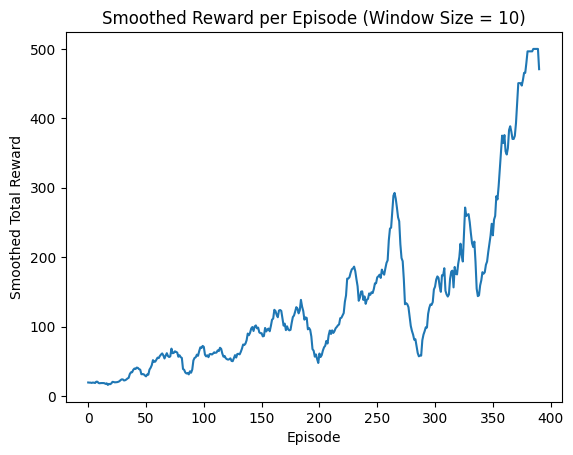

In [19]:
def smooth_rewards(rewards, window_size=10):
    smoothed_rewards = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
    return smoothed_rewards

smoothed_episode_rewards = smooth_rewards(episode_rewards, window_size=10)

plt.plot(smoothed_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Smoothed Reward per Episode (Window Size = 10)")
plt.show()

In [20]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import torch

def record_video(env_name, policy, output_dir="videos"):
    env = gym.make(env_name, render_mode="rgb_array")
    video_env = RecordVideo(env, video_folder=output_dir, episode_trigger=lambda x: True)
    
    state, _ = video_env.reset()
    state = torch.tensor(state, dtype=torch.float32)
    done = False
    truncated = False
    total_reward = 0

    while not done and not truncated:
        action, _ = policy.get_action(state)
        next_state, reward, done, truncated, _ = video_env.step(action)
        total_reward += reward
        state = torch.tensor(next_state, dtype=torch.float32)

    video_env.close()
    print(f"Total Reward: {total_reward}")

record_video(env_name="CartPole-v1", policy=trainer.policy, output_dir="videos")


C:\Users\Work\gpu_env\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at C:\Users\Work\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Total Reward: 500.0


In [22]:
import base64
from IPython.display import HTML

def encode_video_to_base64(video_path):
    with open(video_path, "rb") as video_file:
        video_base64 = base64.b64encode(video_file.read()).decode('utf-8')
    return video_base64

def display_video_in_notebook(video_path):
    video_base64 = encode_video_to_base64(video_path)
    video_html = f"""
    <video width="640" height="480" controls mute autoplay loop>
        <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
        Your browser does not support the video tag.
    </video>
    """
    return HTML(video_html)
display_video_in_notebook("Videos/rl-video-episode-0.mp4")


<p class="task" id="2"></p>

2\. Повторите решение задачи 1, делая шаг обучения не после одного эпизода, а по результату прогонов нескольких эпизодов. Обратите внимание, что после обновления весов модели все старые данные для обучения становятся неактуальными и должны быть удалены.

- [ ] Проверено на семинаре

In [23]:
class BatchTrainer(Trainer):
    def __init__(self, env_name: str, policy_config: PolicyConfig, train_config: TrainConfig, batch_size: int):
        super().__init__(env_name, policy_config, train_config)
        self.batch_size = batch_size

    def train(self):
        episode_rewards = []
        batch_rewards = []
        batch_log_probs = []

        for episode in tqdm(range(self.episode_num)):
            state, _ = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32)
            log_probs = []
            rewards = []

            done = False
            truncated = False
            while not done and not truncated:
                action, log_prob = self.policy.get_action(state)
                next_state, reward, done, truncated, _ = self.env.step(action)
                log_probs.append(log_prob)
                rewards.append(reward)
                state = torch.tensor(next_state, dtype=torch.float32)

            batch_rewards.extend(rewards)
            batch_log_probs.extend(log_probs)
            episode_rewards.append(sum(rewards))

            if (episode + 1) % self.batch_size == 0:
                discounted_rewards = self.calculate_discounted_rewards(batch_rewards)
                discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

                loss = 0
                for log_prob, G in zip(batch_log_probs, discounted_rewards):
                    loss += -log_prob * G
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                batch_rewards = []
                batch_log_probs = []

        return episode_rewards


In [30]:
# Конфигурация
env_name = "CartPole-v1"
policy_config = PolicyConfig(n_state=4, n_action=2, n_hidden=512)
train_config = TrainConfig(gamma=0.99, learning_rate=0.001, episode_num=400)

batch_trainer = BatchTrainer(env_name=env_name, policy_config=policy_config, train_config=train_config, batch_size=5)

episode_rewards = batch_trainer.train()

batch_trainer.play()


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:07<00:00, 56.99it/s]


Total Reward: 139.0


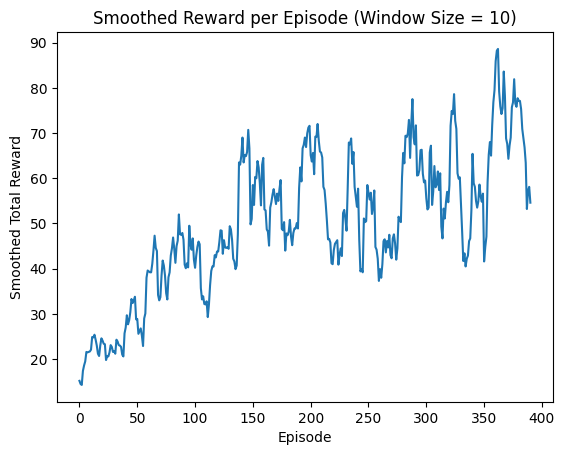

In [31]:
smoothed_episode_rewards = smooth_rewards(episode_rewards, window_size=10)

plt.plot(smoothed_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Smoothed Reward per Episode (Window Size = 10)")
plt.show()

<p class="task" id="3"></p>

3\. Повторите решение задачи 1, реализовав алгоритм REINFONCE с baseline.

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи двух независимых сетей. Сеть для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Сеть для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Настройка весов обеих моделей происходит после каждого эпизода.

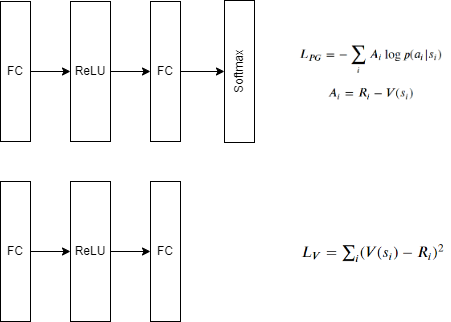

- [ ] Проверено на семинаре

In [33]:
class ValueNetwork(nn.Module):
    def __init__(self, policy_config: PolicyConfig):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(policy_config.n_state, policy_config.n_hidden),
            nn.ReLU(),
            nn.Linear(policy_config.n_hidden, 1)
        )

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        return self.model(s)


class REINFORCEWithBaseline:
    def __init__(self, env_name: str, policy_config: PolicyConfig, train_config: TrainConfig):
        self.env = gym.make(env_name,render_mode="rgb_array")
        self.policy = PolicyNetwork(policy_config)
        self.value = ValueNetwork(policy_config)
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=train_config.learning_rate)
        self.value_optimizer = optim.Adam(self.value.parameters(), lr=train_config.learning_rate)
        self.gamma = train_config.gamma
        self.episode_num = train_config.episode_num

    def calculate_discounted_rewards(self, rewards):
        discounted_rewards = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            discounted_rewards.insert(0, G)
        return torch.tensor(discounted_rewards, dtype=torch.float32)

    def train(self):
        episode_rewards = []

        for episode in tqdm(range(self.episode_num)):
            state, _ = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32)
            log_probs = []
            rewards = []
            values = []

            done = False
            truncated = False

            # Сбор данных
            while not done and not truncated:
                action, log_prob = self.policy.get_action(state)
                value = self.value(state).squeeze()  # Оценка V(s)
                next_state, reward, done, truncated, _ = self.env.step(action)

                log_probs.append(log_prob)
                rewards.append(reward)
                values.append(value)

                state = torch.tensor(next_state, dtype=torch.float32)

            # Вычисление дисконтированных наград
            discounted_rewards = self.calculate_discounted_rewards(rewards)

            # Преобразование значений для Advantage
            values = torch.stack(values)
            advantages = discounted_rewards - values.detach()  # A_i = R_i - V(s_i)

            # Обновление политики (L_PG)
            policy_loss = (-torch.stack(log_probs) * advantages).sum()
            self.policy_optimizer.zero_grad()
            policy_loss.backward()
            self.policy_optimizer.step()

            # Обновление ценности (L_V)
            value_loss = ((values - discounted_rewards) ** 2).sum()
            self.value_optimizer.zero_grad()
            value_loss.backward()
            self.value_optimizer.step()

            episode_rewards.append(sum(rewards))

        return episode_rewards

    def play(self):
        state, _ = self.env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        done = False
        truncated = False
        total_reward = 0

        while not done and not truncated:
            self.env.render()
            action, _ = self.policy.get_action(state)
            next_state, reward, done, truncated, _ = self.env.step(action)
            total_reward += reward
            state = torch.tensor(next_state, dtype=torch.float32)

        self.env.close()
        print(f"Total Reward: {total_reward}")



env_name = "CartPole-v1"
policy_config = PolicyConfig(n_state=4, n_action=2, n_hidden=512)
train_config = TrainConfig(gamma=0.99, learning_rate=0.001, episode_num=400)

# Создание и обучение агента
agent = REINFORCEWithBaseline(env_name, policy_config, train_config)
episode_rewards = agent.train()


# Тестирование агента
agent.play()


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:50<00:00,  7.87it/s]


Total Reward: 500.0


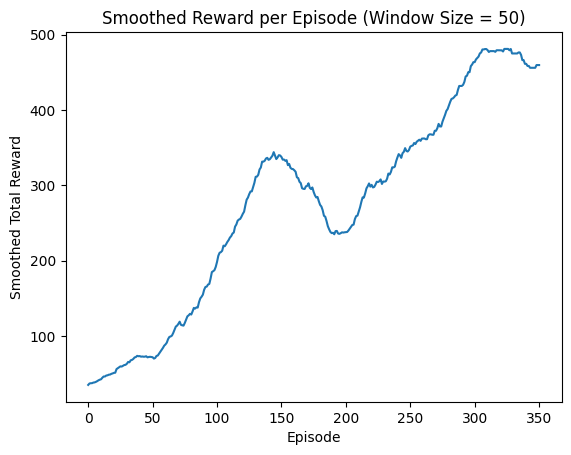

In [38]:
smoothed_episode_rewards = smooth_rewards(episode_rewards, window_size=50)
plt.plot(smoothed_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Smoothed Reward per Episode (Window Size = 50)")
plt.show()

In [36]:
record_video(env_name="CartPole-v1", policy=agent.policy, output_dir="videos")
display_video_in_notebook("Videos/rl-video-episode-0.mp4")

Total Reward: 500.0


<p class="task" id="4"></p>

4\. Повторите решение задачи 1, реализовав алгоритм Actor-Critic

$$L_{PG} = -\sum_{i}{A_i\log{p(a_i|s_i)}}$$

$$A_i = R_i - V(s_i)$$

$$R_t = \sum_{k=0}^{\infty}\gamma^kr_{t+k}$$

где $r_t$ - награда за шаг $t$.

$p(a_i|s_i)$ и $V(s_i)$ моделируются при помощи одной сети в двумя головами. Голова для политики настраивается аналогично задаче 1 и 2 при помощи функции потерь $L_{PG}$. Голова для оценки базы настраивается в процессе решения задачи регрессии: $L_{V} = \sum_i(V(s_i) - R_i)^2$. Итоговая функции потерь для настройки представляет из себя сумму функций потерь для голов: $L = L_{PG} + L_{V}$.

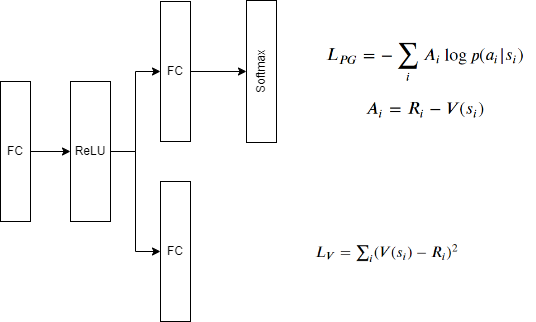

- [ ] Проверено на семинаре

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from torch.distributions import Categorical
from dataclasses import dataclass
from tqdm import tqdm
import matplotlib.pyplot as plt


class ActorCriticNetwork(nn.Module):
    def __init__(self, policy_config: PolicyConfig):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(policy_config.n_state, policy_config.n_hidden),
            nn.ReLU()
        )
        # Головная часть для политики
        self.policy_head = nn.Sequential(
            nn.Linear(policy_config.n_hidden, policy_config.n_action),
            nn.Softmax(dim=-1)
        )
        # Головная часть для оценки состояния
        self.value_head = nn.Linear(policy_config.n_hidden, 1)

    def forward(self, s: torch.Tensor):
        shared_out = self.shared(s)
        policy = self.policy_head(shared_out)
        value = self.value_head(shared_out)
        return policy, value


class ActorCriticTrainer:
    def __init__(self, env_name: str, policy_config: PolicyConfig, train_config: TrainConfig):
        self.env = gym.make(env_name,render_mode="rgb_array")
        self.model = ActorCriticNetwork(policy_config)
        self.optimizer = optim.Adam(self.model.parameters(), lr=train_config.learning_rate)
        self.gamma = train_config.gamma
        self.episode_num = train_config.episode_num

    def calculate_discounted_rewards(self, rewards):
        discounted_rewards = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            discounted_rewards.insert(0, G)
        return torch.tensor(discounted_rewards, dtype=torch.float32)

    def train(self):
        episode_rewards = []

        for episode in tqdm(range(self.episode_num)):
            state, _ = self.env.reset()
            state = torch.tensor(state, dtype=torch.float32)
            log_probs = []
            rewards = []
            values = []

            done = False
            truncated = False

            # Сбор данных
            while not done and not truncated:
                policy, value = self.model(state)
                dist = Categorical(policy)
                action = dist.sample()
                log_prob = dist.log_prob(action)
                next_state, reward, done, truncated, _ = self.env.step(action.item())

                log_probs.append(log_prob)
                rewards.append(reward)
                values.append(value)

                state = torch.tensor(next_state, dtype=torch.float32)

            # Вычисление дисконтированных наград
            discounted_rewards = self.calculate_discounted_rewards(rewards)
            values = torch.stack(values).squeeze()

            # Advantage для политики
            advantages = discounted_rewards - values.detach()

            # Функция потерь для политики (L_PG)
            policy_loss = (-torch.stack(log_probs) * advantages).sum()

            # Функция потерь для оценки состояния (L_V)
            value_loss = ((values - discounted_rewards) ** 2).sum()

            # Итоговая функция потерь
            loss = policy_loss + value_loss

            # Обновление параметров
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            episode_rewards.append(sum(rewards))

        return episode_rewards

    def play(self):
        state, _ = self.env.reset()
        state = torch.tensor(state, dtype=torch.float32)
        done = False
        truncated = False
        total_reward = 0

        while not done and not truncated:
            self.env.render()
            policy, _ = self.model(state)
            action = Categorical(policy).sample().item()
            next_state, reward, done, truncated, _ = self.env.step(action)
            total_reward += reward
            state = torch.tensor(next_state, dtype=torch.float32)

        self.env.close()
        print(f"Total Reward: {total_reward}")


# Конфигурация
env_name = "CartPole-v1"
policy_config = PolicyConfig(n_state=4, n_action=2, n_hidden=256)
train_config = TrainConfig(gamma=0.99, learning_rate=0.001, episode_num=400)

# Обучение
trainer = ActorCriticTrainer(env_name, policy_config, train_config)
episode_rewards = trainer.train()

# Тестирование
trainer.play()


100%|████████████████████████████████████████████████████████████████████████████████| 400/400 [00:15<00:00, 25.50it/s]


Total Reward: 114.0


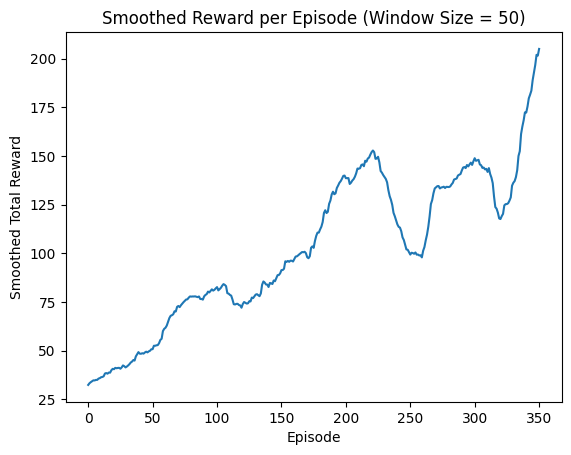

In [47]:
smoothed_episode_rewards = smooth_rewards(episode_rewards, window_size=50)
plt.plot(smoothed_episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Smoothed Reward per Episode (Window Size = 50)")
plt.show()

## Обратная связь
- [ ] Хочу получить обратную связь по решению